In [24]:
%pip install pandas
import pandas as pd

df = pd.read_csv('Data\Nazario.csv')
print(df['label'].value_counts())

SyntaxError: (unicode error) 'unicodeescape' codec can't decode bytes in position 4-5: malformed \N character escape (349452005.py, line 4)

# Remove Duplicates
This step removes duplicate rows and confirms how many were removed.

In [ ]:
print("--- Remove Duplicates ---")

rows_before = len(df)
duplicate_rows_before = df.duplicated().sum()

print(f"Rows before: {rows_before}")
print(f"Duplicate rows found: {duplicate_rows_before}")

# Remove duplicate rows
df = df.drop_duplicates().copy()

rows_after = len(df)
duplicate_rows_after = df.duplicated().sum()
removed_duplicates = rows_before - rows_after

print(f"Rows after: {rows_after}")
print(f"Duplicate rows after cleaning: {duplicate_rows_after}")
print(f"Removed duplicate rows: {removed_duplicates}")

--- Remove Duplicates ---
Rows before: 0
Duplicate rows found: 0
Rows after: 0
Duplicate rows after cleaning: 0
Removed duplicate rows: 0


# Remove Unwanted Outliers
This step uses the IQR rule on numeric columns and confirms how many rows were removed as outliers.

In [ ]:
import numpy as np

print("--- Remove Unwanted Outliers (IQR) ---")

rows_before = len(df)
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

if not numeric_cols:
    print("No numeric columns found. Skipping outlier removal.")
else:
    mask = pd.Series(True, index=df.index)

    for col in numeric_cols:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1

        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        col_mask = df[col].between(lower, upper) | df[col].isna()
        mask &= col_mask

    df = df[mask].copy()

rows_after = len(df)
removed_outliers = rows_before - rows_after

print(f"Rows before: {rows_before}")
print(f"Rows after: {rows_after}")
print(f"Outlier rows removed: {removed_outliers}")

--- Remove Unwanted Outliers (IQR) ---
No numeric columns found. Skipping outlier removal.
Rows before: 0
Rows after: 0
Outlier rows removed: 0


# Handle Missing Values
This step fills missing values and confirms the total missing count before and after cleaning.

In [ ]:
print("--- Handle Missing Values ---")

missing_before = int(df.isna().sum().sum())
print(f"Missing values before: {missing_before}")

numeric_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(include=["object", "category"]).columns

for col in numeric_cols:
    if df[col].isna().any():
        df[col] = df[col].fillna(df[col].median())

for col in categorical_cols:
    if df[col].isna().any():
        mode_values = df[col].mode(dropna=True)
        fill_value = mode_values.iloc[0] if not mode_values.empty else "Unknown"
        df[col] = df[col].fillna(fill_value)

missing_after = int(df.isna().sum().sum())
filled_values = missing_before - missing_after

print(f"Missing values after: {missing_after}")
print(f"Missing values filled: {filled_values}")

--- Handle Missing Values ---
Missing values before: 0
Missing values after: 0
Missing values filled: 0


In [ ]:
print("--- Final Cleaning Check ---")
print(f"Final rows: {len(df)}")
print(f"Remaining duplicate rows: {int(df.duplicated().sum())}")
print(f"Remaining missing values: {int(df.isna().sum().sum())}")

df.head()

--- Final Cleaning Check ---
Final rows: 0
Remaining duplicate rows: 0
Remaining missing values: 0


""


# H1: Graph of Rows and Columns
This graph shows the total number of rows and columns in the cleaned DataFrame.

--- Graph: Rows vs Columns ---
Rows: 0
Columns: 0


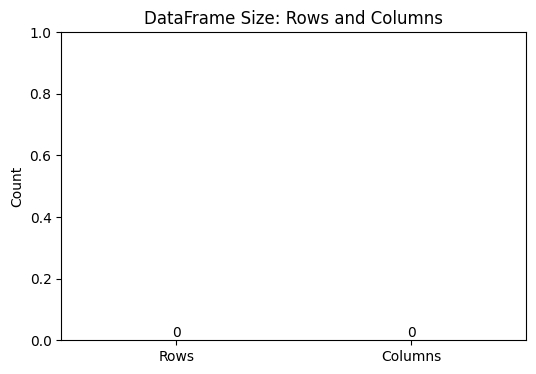

In [ ]:
import matplotlib.pyplot as plt

print("--- Graph: Rows vs Columns ---")

row_count, column_count = df.shape
print(f"Rows: {row_count}")
print(f"Columns: {column_count}")

labels = ["Rows", "Columns"]
values = [row_count, column_count]

plt.figure(figsize=(6, 4))
bars = plt.bar(labels, values, color=["#1f77b4", "#ff7f0e"])
plt.title("DataFrame Size: Rows and Columns")
plt.ylabel("Count")

for bar, value in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width() / 2, value, str(value), ha="center", va="bottom")

plt.ylim(0, max(values) + 1 if max(values) > 0 else 1)
plt.show()